In [1]:
from pathlib import Path
import sys
import os

HOME = Path.cwd().parent
sys.path.append(str(HOME))
print("当前工作目录:", os.getcwd())

当前工作目录: /root/autodl-tmp/main/notebook


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from battery_data import BatteryData

def show_V(battery_data: BatteryData, figsize: tuple = (12, 6)) -> plt.Figure:
    
    # 创建图形
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # 配置颜色映射（从红色到蓝色，表示SOH从低到高）
    soh_values = []
    for cycle in battery_data.cycle_data:
        soh_values.append(cycle.labeled_soh)
    soh_min = min(soh_values)
    soh_max = max(soh_values)
    cmap = plt.colormaps['coolwarm']
    
    # 绘制电压-时间曲线
    for cycle in battery_data.cycle_data:
        voltage = cycle.labeled_V
        Qc = cycle.labeled_Qc
        
        # 根据SOH选择颜色
        soh = cycle.labeled_soh 
        soh_norm = (soh - soh_min) / (soh_max - soh_min) if soh_max != soh_min else 0.5
        color = cmap(soh_norm)
        
        ax.plot(voltage, Qc, color=color, alpha=0.7, linewidth=1)
    
    # 设置图表属性
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('Charge Capacity (Ah)')
    ax.set_title(f'Voltage vs Charge Capacity - {battery_data.cell_id}')
    
    # 添加颜色条表示SOH
    norm = mcolors.Normalize(vmin=soh_min*100, vmax=soh_max*100)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('State of Health (SOH) %')
    
    ax.grid(True, alpha=0.3)
    ax.autoscale()
    
    plt.tight_layout()
    
    return fig


import gc

#### CALCE

55

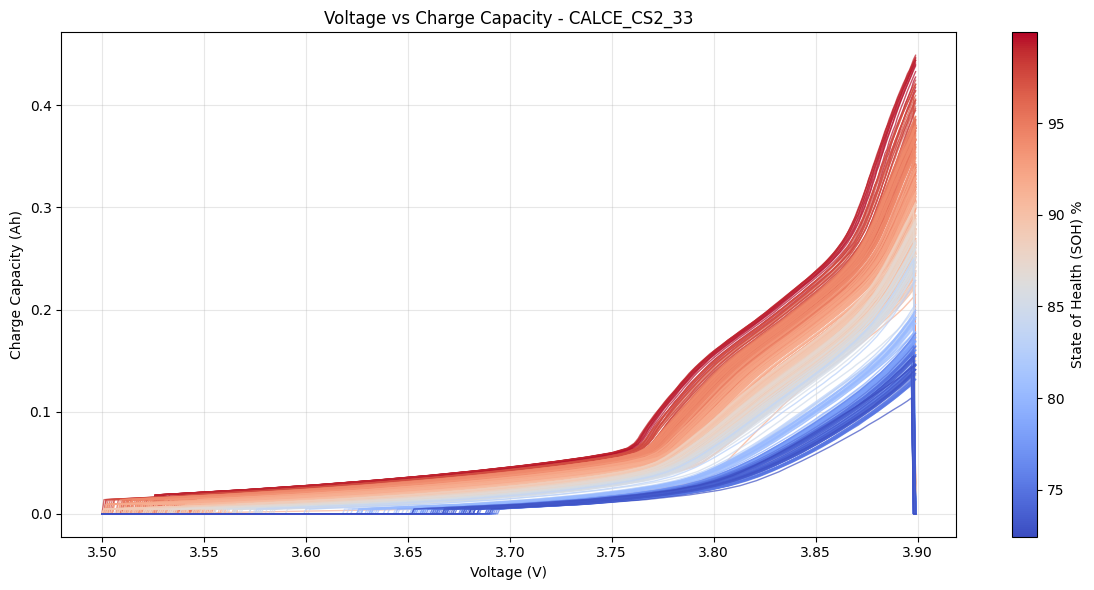

In [3]:
dir = '../data/labeled/train/CALCE_CS2_33.pkl'
battery = BatteryData.load(dir)
_ = show_V(battery)
del battery
gc.collect() 

#### HNEI

45603

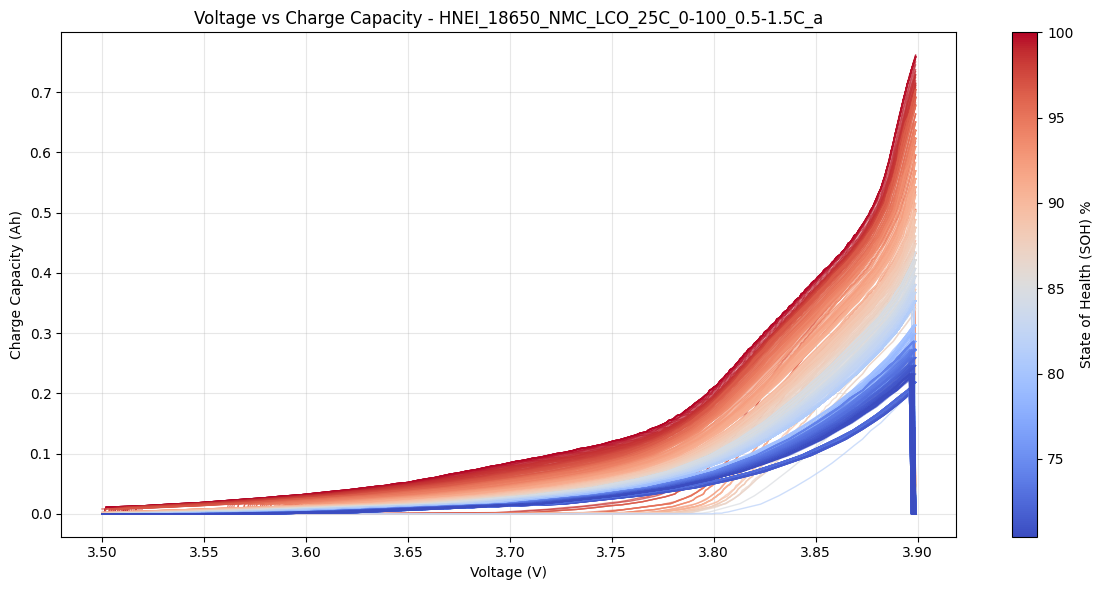

In [4]:
dir = '../data/labeled/train/HNEI_18650_NMC_LCO_25C_0-100_0.5-1.5C_a.pkl'
battery = BatteryData.load(dir)
_ = show_V(battery)
del battery
gc.collect() 

#### HUST

51618

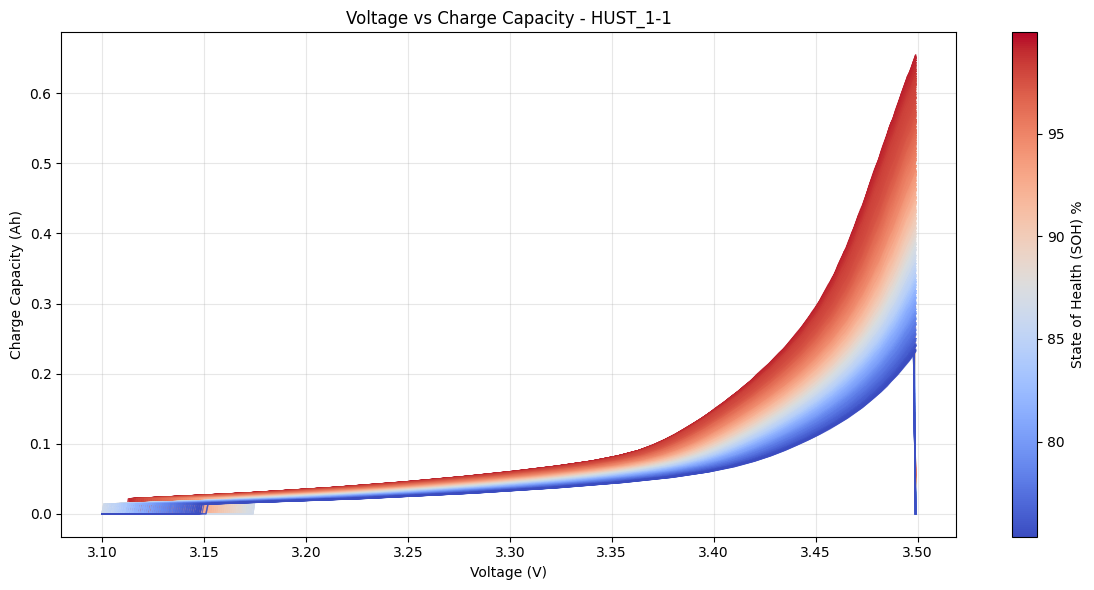

In [5]:
dir = '../data/labeled/test_HUST/HUST_1-1.pkl'
battery = BatteryData.load(dir)
_ = show_V(battery)
del battery
gc.collect() 

#### MATR

1664


119134

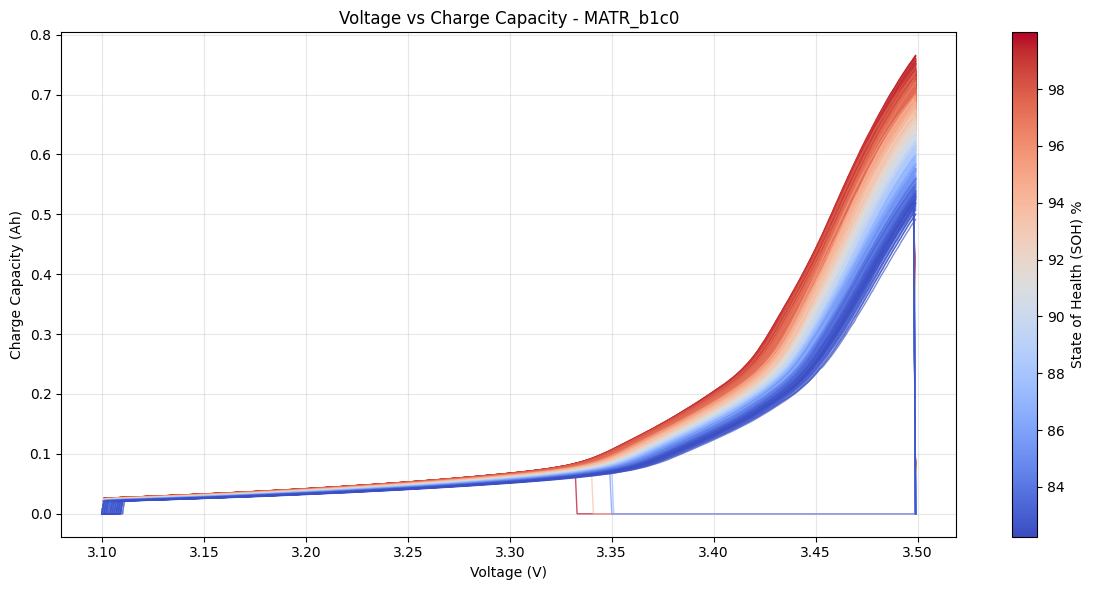

In [6]:
dir = '../data/labeled/train/MATR_b1c0.pkl'
battery = BatteryData.load(dir)
print(len(battery.cycle_data))
_ = show_V(battery)
del battery
gc.collect() 

#### RWTH

132086

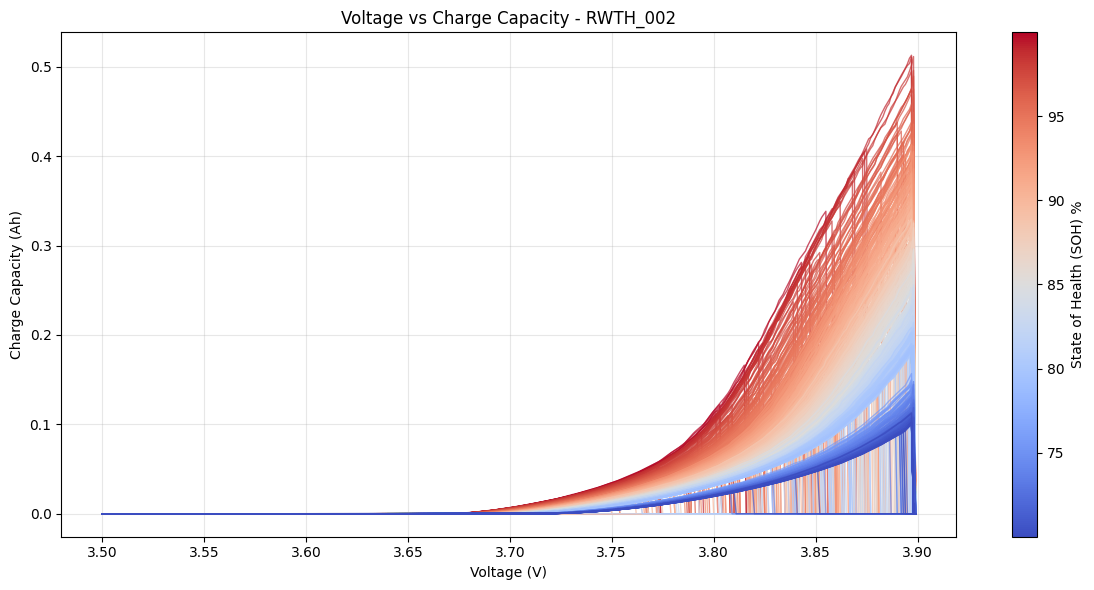

In [7]:
dir = '../data/labeled/test_RWTH/RWTH_002.pkl'
battery = BatteryData.load(dir)
_ = show_V(battery)
del battery
gc.collect() 

In [29]:
from collections import defaultdict
from pathlib import Path
from battery_data import BatteryData
import numpy as np
import json


# 统计每个数据集的循环数量与每个循环的 labeled_Qc 长度
DATASETS = ['CALCE', 'HNEI', 'HUST', 'MATR', 'RWTH', 'SNL', 'UL_PUR']
base_dir = Path('../data/labeled')
stats = {}

for ds in DATASETS:
    ds_dir = base_dir / ds
    pkl_files = sorted(ds_dir.glob('*.pkl'))
    cycle_counts = []
    qc_lengths = []
    for pkl in pkl_files:
        battery = BatteryData.load(str(pkl))
        cycle_counts.append(len(battery.cycle_data))
        for cycle in battery.cycle_data:
            qc_lengths.append(len(cycle.labeled_Qc))
    if cycle_counts:
        stats[ds] = {
            'num_batteries': len(cycle_counts),
            'cycle_count_avg': float(np.mean(cycle_counts)),
            'cycle_count_min': int(np.min(cycle_counts)),
            'cycle_count_max': int(np.max(cycle_counts)),
            'qc_len_per_cycle_avg': float(np.mean(qc_lengths)) if qc_lengths else 0.0,
        }
    else:
        stats[ds] = {
            'num_batteries': 0,
            'cycle_count_avg': 0.0,
            'cycle_count_min': 0,
            'cycle_count_max': 0,
            'qc_len_per_cycle_avg': 0.0,
        }

print(json.dumps(stats, indent=2, ensure_ascii=False))

{
  "CALCE": {
    "num_batteries": 13,
    "cycle_count_avg": 790.0769230769231,
    "cycle_count_min": 418,
    "cycle_count_max": 1232,
    "qc_len_per_cycle_avg": 400.0
  },
  "HNEI": {
    "num_batteries": 14,
    "cycle_count_avg": 519.7857142857143,
    "cycle_count_min": 458,
    "cycle_count_max": 598,
    "qc_len_per_cycle_avg": 400.0
  },
  "HUST": {
    "num_batteries": 77,
    "cycle_count_avg": 1801.987012987013,
    "cycle_count_min": 1140,
    "cycle_count_max": 2687,
    "qc_len_per_cycle_avg": 400.0
  },
  "MATR": {
    "num_batteries": 167,
    "cycle_count_avg": 753.6407185628742,
    "cycle_count_min": 217,
    "cycle_count_max": 2147,
    "qc_len_per_cycle_avg": 400.0
  },
  "RWTH": {
    "num_batteries": 48,
    "cycle_count_avg": 1031.9166666666667,
    "cycle_count_min": 893,
    "cycle_count_max": 1256,
    "qc_len_per_cycle_avg": 400.0
  },
  "SNL": {
    "num_batteries": 0,
    "cycle_count_avg": 0.0,
    "cycle_count_min": 0,
    "cycle_count_max": 0,
    "